In [1]:
ssptransfer = None
src_model = "KACE-1-0-G"  
tgt_model = "EC-Earth3"  

tfmodel = 'transformer'

home_dir = os.path.expanduser('~/')
data_dir = home_dir+'/data/'
ML_dir = home_dir+'/research/Machine_Learning/MLresults/'
SSPLIST = [126,245,585]

set_input = 10 
selmodes = 8
pclen_loop = 10
year_start = 1995
year_end = 2100

ny, nx = 512, 512
nt = 1272
nt_seq = nt - 3

titleabc = ["A ", "B ", "C ", "D ", "E ", "F ", "G ", "H "]
title_ssp=["SSP1-2.6", "SSP2-4.5","SSP5-8.5"]


xr_ns_to_year = 1e9 * 60 * 60 * 24 * 365.25  


In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import xarray as xr
import matplotlib.pyplot as plt
from glob import glob
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerTuple

import matplotlib.dates as mdates


from CEDL_functions import load_sst_fields, load_eofs_pcs, predict_target_pcs,reconstructiont_eofs_cedl, load_X_dataset

2026-07-23 12:15:24.983649: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# load dataset

In [3]:
TIME = pd.date_range("1995-01", "2100-12", freq="MS") + pd.offsets.Day(14)
TIME_seq = pd.date_range("1995-04", "2100-12", freq="MS") + pd.offsets.Day(14)
TIME_yearly = pd.date_range("1995-04", "2100-12", freq="YS") + pd.offsets.Day(14) 
year_start = 1995
seq_length = 4
seqnt = seq_length - 1

varY_name = "SST"  

varlist_X = ["tas", "uas", "vas", "huss", "rlds", "rsds"]
var_trendX = ["tas_PC1", "huss_PC1", "rlds_PC1"]
var_trendY = "SST_PC1"
var_Physical = [
    "tas_PC1",
    "uas_PC1",
    "vas_PC1",
    "huss_PC1",
    "rlds_PC1",
    "rsds_PC1",
] 


In [4]:
dict_load_sst_fields = load_sst_fields(src_model, tgt_model, year_end)

sst_src = dict_load_sst_fields["sst_src"]
sst_src_mc = dict_load_sst_fields["sst_src_mc"]
sst_src_histmc = dict_load_sst_fields["sst_src_histmc"]

sst_tgt = dict_load_sst_fields["sst_tgt"]
sst_tgt_mc = dict_load_sst_fields["sst_tgt_mc"]
sst_tgt_anom = dict_load_sst_fields["sst_tgt_anom"]
sst_tgt_anom_sm = dict_load_sst_fields["sst_tgt_anom_sm"]


sst_src_sm_yr = sst_src.groupby("time.year").mean(["time",'lon','lat']).isel(year=slice(1,None)).compute()
sst_tgt_sm_yr = sst_tgt.groupby("time.year").mean(["time",'lon','lat']).isel(year=slice(1,None)).compute()



In [5]:
lat = sst_tgt.lat
lon = sst_tgt.lon
msk = sst_tgt.maskC
minlon = sst_tgt.lon.min().values
minlat = sst_tgt.lat.min().values
maxlon = sst_tgt.lon.max().values
maxlat = sst_tgt.lat.max().values
minlon, maxlon, minlat, maxlat

(array(117.04166412), array(159.625), array(20.03914452), array(53.18893814))

In [6]:
dict_load_eofs_pcs = load_eofs_pcs(src_model, tgt_model, SSPLIST, varlist_X, data_dir, year_start, nt, TIME, 0,set_input=10)

pcs_X_src = dict_load_eofs_pcs['pcs_X_src']
pcs_X_tgt = dict_load_eofs_pcs['pcs_X_tgt']
pcs_X_src = dict_load_eofs_pcs['pcs_X_src']


pcs_Y_src = dict_load_eofs_pcs['pcs_Y_src']  #! (mode, lat, lon)
eofs_Y_src = dict_load_eofs_pcs['eofs_Y_src']  #! (mode, lat, lon)
wgts_Y_src = dict_load_eofs_pcs['wgts_Y_src']

eofs_Y_src = eofs_Y_src.where(sst_src.maskC).persist()
pcs_X_tgt


 -----------Executing function: load_XandY----------

 -----------Executing function: load_XandY----------

 -----------Executing function: load_Y_dataset----------

 -----------Executing function: load_XandY----------

 -----------Executing function: load_XandY----------

 -----------Executing function: load_Y_dataset----------

 -----------Executing function: load_XandY----------

 -----------Executing function: load_XandY----------

 -----------Executing function: load_Y_dataset----------


{126: mode                 tas_PC1  tas_PC2  tas_PC3  tas_PC4  tas_PC5  tas_PC6  \
 time                                                                        
 1995-01-16 12:00:00  -2.9482   1.0812  -0.9926  -0.2027   0.3209  -0.8484   
 1995-02-15 00:00:00  -2.8175   1.2925  -1.2102  -0.6915  -0.3160  -1.8716   
 1995-03-16 12:00:00  -2.6723   0.1095   0.1426  -0.5367   1.3214  -1.0033   
 1995-04-16 00:00:00  -2.5919   0.1671   1.4334  -0.8065  -0.9386  -0.9730   
 1995-05-16 12:00:00  -2.3772   0.3976   0.3710  -0.2130  -1.0162  -0.4374   
 ...                      ...      ...      ...      ...      ...      ...   
 2100-08-16 12:00:00   0.7259  -1.1691   0.2739  -0.8519  -0.4739   0.3997   
 2100-09-16 00:00:00   0.5459  -1.4086   0.4314   0.0389  -0.0379  -0.7443   
 2100-10-16 12:00:00   0.8887  -1.3311   0.6641   1.2011   0.6176   0.1847   
 2100-11-16 00:00:00   0.5518   1.0574   1.9858  -0.7408   2.1381   0.2456   
 2100-12-16 12:00:00  -0.3806   0.7416   2.8314   0.2239  -

# predict PC timeseries

In [7]:
pred_Y_tgt = predict_target_pcs(SSPLIST,  ML_dir, pclen_loop, pcs_X_tgt, seq_length, var_trendX, TIME_seq, ssptransfer=ssptransfer,src_model=src_model, useEOF85=0, tfmodel=tfmodel,set_input=set_input)

InPc10_Train_KACE-1-0-G_6xvar_SST_ssp126_transformer
/home/dhkim//research/Machine_Learning/MLresults//InPc10_Train_KACE-1-0-G_6xvar_SST_ssp126_transformer
SSP: 126 | Mode: 0

 -----------Executing function: preprocessing_trend----------
(1269, 4, 20)
X_train_trend shape: (1269,)
SSP: 126 | Mode: 1

 -----------Executing function: preprocessing_trend----------
(1269, 4, 20)
SSP: 126 | Mode: 2

 -----------Executing function: preprocessing_trend----------
(1269, 4, 20)
SSP: 126 | Mode: 3

 -----------Executing function: preprocessing_trend----------
(1269, 4, 20)
SSP: 126 | Mode: 4

 -----------Executing function: preprocessing_trend----------
(1269, 4, 20)
SSP: 126 | Mode: 5

 -----------Executing function: preprocessing_trend----------
(1269, 4, 20)
SSP: 126 | Mode: 6

 -----------Executing function: preprocessing_trend----------
(1269, 4, 20)
SSP: 126 | Mode: 7

 -----------Executing function: preprocessing_trend----------
(1269, 4, 20)
SSP: 126 | Mode: 8

 -----------Executing funct

# Reconstruct SST fields

In [8]:
cedl_8m_anom = reconstructiont_eofs_cedl(pred_Y_tgt, eofs_Y_src, wgts_Y_src, selmode1=1,selmode2=selmodes, ssp_list=SSPLIST)

cedl_8m = (cedl_8m_anom.groupby("time.month") + sst_src_mc).persist()

bias = cedl_8m.sel(time=slice('1995','2014')).groupby('time.month').mean(['time']) - sst_src_histmc
cedl_8m_adjust = cedl_8m.groupby('time.month') - bias

cedl_8m_sm_yr = cedl_8m_adjust.groupby("time.year").mean(dim="time").mean(["lon", "lat"]).isel(year=slice(1, None)).compute()  
cedl_8m_sm_yr_bias = cedl_8m.groupby("time.year").mean(dim="time").mean(["lon", "lat"]).isel(year=slice(1, None)).compute()  


sst_src_hpc = reconstructiont_eofs_cedl(pcs_Y_src, eofs_Y_src, wgts_Y_src, selmode1=selmodes + 1, selmode2=None, ssp_list=SSPLIST).isel(time=slice(seqnt, None))

cedl_full_anom = (cedl_8m_anom + sst_src_hpc).persist()
cedl_full_anom_sm = cedl_full_anom.mean(["lon", "lat"]).compute()

cedl_full = (cedl_8m_adjust + sst_src_hpc).persist()
cedl_full_sm_yr = cedl_full.groupby("time.year").mean(dim="time").mean(["lon", "lat"]).isel(year=slice(1, None)).compute()


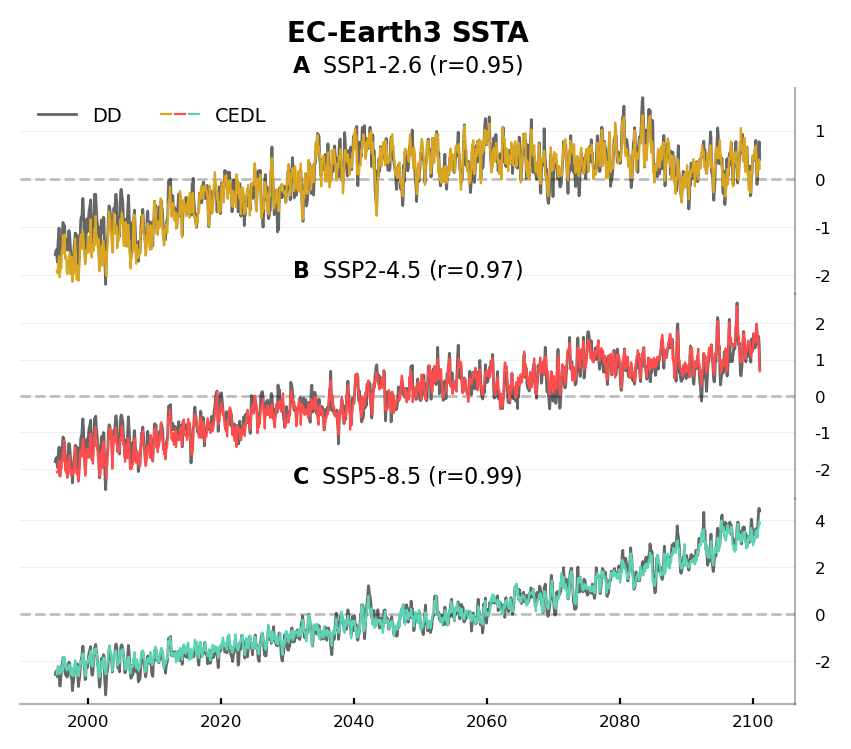

In [9]:
lw_true, lw_pred = 1, .8

ssp_colors = ["#DAA520", "#FF4D4D", "#5DD3B6"]

fig, axes = plt.subplots(3, 1, figsize=(5, 4), dpi=200, gridspec_kw={"hspace": 0.0})

axes[0].annotate(f"{tgt_model} SSTA", xy=(0.5, 1.2), xycoords="axes fraction", ha="center", va="bottom", fontsize=10, fontweight="bold")

for i, ax in enumerate(axes):
    ssp = SSPLIST[i]
    truedata = sst_tgt_anom_sm.sel(ssp=ssp)
    preddata = cedl_full_anom_sm.sel(ssp=ssp)

    ax.plot(TIME[:len(truedata) ], truedata[:], label="DD-SSTA", lw=lw_true, alpha=0.6, color="k", ls="-")
    ax.plot(TIME[seqnt:len(preddata) + seqnt ], preddata[:], label="DL-SSTA", lw=lw_pred, alpha=1, color=ssp_colors[i], ls="-")

    cor = np.corrcoef(truedata[seqnt:], preddata)[0, 1]
    ssp_str = str(ssp)
    ax.set_title(rf"$\mathbf{{{titleabc[i]}}}\;$ SSP{ssp_str[0]}-{ssp_str[1]}.{ssp_str[2]} (r={cor:.2f})", fontsize=8)

    ax.grid(False)
    ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
    ax.axhline(0, color="gray", zorder=0, lw=1, ls="--", alpha=0.5)
    ax.tick_params(axis="both", which="both", left=False, right=False, labelleft=False, labelright=True, labelsize=6)
    ax.grid(True, which='major', axis='y', alpha=0.3, linestyle='-', linewidth=0.25)

    ax.spines["right"].set_visible(True)
    ax.spines["right"].set_alpha(0.3)

    if i == len(axes) - 1:
        ax.spines["bottom"].set_visible(True)
        ax.spines["bottom"].set_alpha(0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.tick_params(axis="x", which="major", direction='in', bottom=True, labelbottom=True, length=2)
    else:
        ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

# 커스텀 범례 설정 (첫 번째 서브플롯에 위치)
line_true = mlines.Line2D([], [], lw=lw_true, alpha=0.6, color="k", ls="-")
line_ssp1 = mlines.Line2D([], [], color="#DAA520", lw=lw_pred)
line_ssp2 = mlines.Line2D([], [], color="#FF4D4D", lw=lw_pred)
line_ssp5 = mlines.Line2D([], [], color="#5DD3B6", lw=lw_pred)

axes[0].legend([line_true, (line_ssp1, line_ssp2, line_ssp5)], ["DD", "CEDL"], 
               handler_map={tuple: HandlerTuple(ndivide=None, pad=0.2)}, frameon=False, loc="upper left", ncol=2, fontsize=7)


# Ensemble plot

In [10]:


ens_list = [
    "ACCESS-CM2",     
    "AWI-CM-1-1-MR",  
    "BCC-CSM2-MR",    
    "CMCC-CM2-SR5",   
    "CanESM5-1",      
    "FGOALS-f3-L",    
    "GFDL-ESM4", 
    "IPSL-CM6A-LR", 
    "KIOST-ESM", 
    "MIROC6",         
    "MPI-ESM1-2-LR",  
    "MRI-ESM2-0",     
    "NorESM2-LM",
]
ens_list = [tgt_model]+ens_list
ens_list

['EC-Earth3',
 'ACCESS-CM2',
 'AWI-CM-1-1-MR',
 'BCC-CSM2-MR',
 'CMCC-CM2-SR5',
 'CanESM5-1',
 'FGOALS-f3-L',
 'GFDL-ESM4',
 'IPSL-CM6A-LR',
 'KIOST-ESM',
 'MIROC6',
 'MPI-ESM1-2-LR',
 'MRI-ESM2-0',
 'NorESM2-LM']

In [11]:

pred_Y_ens = {}
for model in ens_list:
    pcs_X_ens={}
    print(f"Predicting for target model: {model}")
    for ssp in SSPLIST:
        pcs_X_ens[ssp] = load_X_dataset(
            model=model,
            SSP=ssp,
            varlist=varlist_X,
            set_input=set_input,
            useEOF85=0,
            data_dir=data_dir,
            year_start=year_start,
        )

    pred_Y_ens[model] = predict_target_pcs(SSPLIST,  ML_dir, pclen_loop, pcs_X_ens, seq_length, var_trendX, TIME_seq, ssptransfer=ssptransfer,src_model=src_model, tfmodel=tfmodel,set_input=set_input)

Predicting for target model: EC-Earth3

 -----------Executing function: load_XandY----------

 -----------Executing function: load_XandY----------

 -----------Executing function: load_XandY----------
InPc10_Train_KACE-1-0-G_6xvar_SST_ssp126_transformer
/home/dhkim//research/Machine_Learning/MLresults//InPc10_Train_KACE-1-0-G_6xvar_SST_ssp126_transformer
SSP: 126 | Mode: 0

 -----------Executing function: preprocessing_trend----------
(1269, 4, 20)
X_train_trend shape: (1269,)
SSP: 126 | Mode: 1

 -----------Executing function: preprocessing_trend----------
(1269, 4, 20)
SSP: 126 | Mode: 2

 -----------Executing function: preprocessing_trend----------
(1269, 4, 20)
SSP: 126 | Mode: 3

 -----------Executing function: preprocessing_trend----------
(1269, 4, 20)
SSP: 126 | Mode: 4

 -----------Executing function: preprocessing_trend----------
(1269, 4, 20)
SSP: 126 | Mode: 5

 -----------Executing function: preprocessing_trend----------
(1269, 4, 20)
SSP: 126 | Mode: 6

 -----------Execut

In [12]:

cedl_anom_ens = {}
cedl_full_ens = {}
cedl_full_ens_adjust = {}
cedl_full_ens_sm_yr = {}
cedl_full_ens_adjust_sm_yr={}
for model in ens_list:
    print(f"Reconstructing for target model: {model}")
    cedl_anom_ens[model] = reconstructiont_eofs_cedl(pred_Y_ens[model], eofs_Y_src, wgts_Y_src, selmode1=1,selmode2=selmodes, ssp_list=SSPLIST)
        
    tmp_season = cedl_anom_ens[model].groupby('time.month') + sst_src_mc    
    tmp_seasen_full = tmp_season+sst_src_hpc #! higher-order add
    
    bias = tmp_seasen_full.sel(time=slice('1995-04','2014-12')).groupby('time.month').mean('time') - sst_src_histmc
    cedl_full_ens_adjust[model] = tmp_seasen_full.groupby('time.month') - bias
    
    cedl_full_ens_sm_yr[model] = tmp_seasen_full.groupby('time.year').mean(['time','lon','lat']).isel(year=slice(1,None)).compute()
    cedl_full_ens_adjust_sm_yr[model] = cedl_full_ens_adjust[model].groupby('time.year').mean(['time','lon','lat']).isel(year=slice(1,None)).compute()
    
cedl_full_ens_sm_yr= xr.concat(
    list(cedl_full_ens_sm_yr.values()), 
    dim='model'
).assign_coords(model=list(cedl_full_ens_sm_yr.keys()))

cedl_full_ens_adjust_sm_yr= xr.concat(
    list(cedl_full_ens_adjust_sm_yr.values()), 
    dim='model'
).assign_coords(model=list(cedl_full_ens_adjust_sm_yr.keys()))



Reconstructing for target model: EC-Earth3
Reconstructing for target model: ACCESS-CM2
Reconstructing for target model: AWI-CM-1-1-MR
Reconstructing for target model: BCC-CSM2-MR
Reconstructing for target model: CMCC-CM2-SR5
Reconstructing for target model: CanESM5-1
Reconstructing for target model: FGOALS-f3-L
Reconstructing for target model: GFDL-ESM4
Reconstructing for target model: IPSL-CM6A-LR
Reconstructing for target model: KIOST-ESM
Reconstructing for target model: MIROC6
Reconstructing for target model: MPI-ESM1-2-LR
Reconstructing for target model: MRI-ESM2-0
Reconstructing for target model: NorESM2-LM


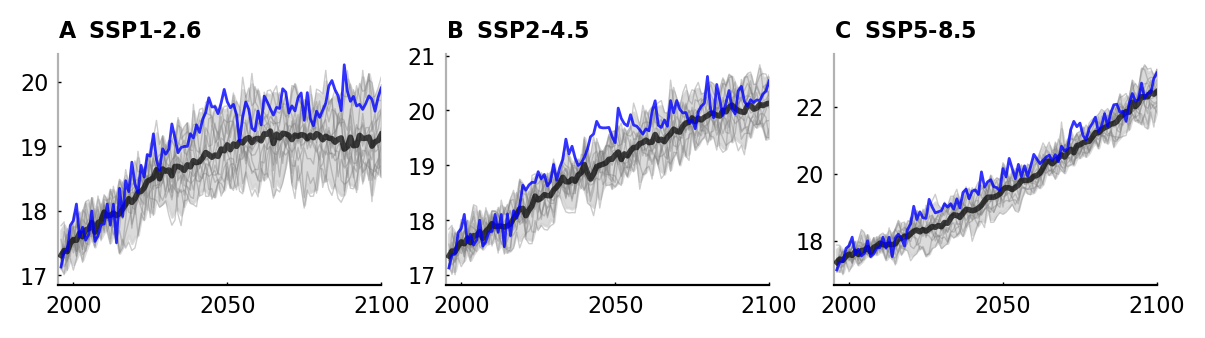

In [14]:
fig,axes = plt.subplots(1,3,figsize=(7.09, 1.50), dpi=200)


for i, ax in enumerate(axes):
    ssp = SSPLIST[i]
    da = cedl_full_ens_adjust_sm_yr.sel(ssp=ssp)
    
    ax.plot(sst_src_sm_yr.year, sst_src_sm_yr.sel(ssp=ssp), label=f"{src_model}, DD", lw=1, alpha=0.8, color="b", ls="-", zorder=1)

    for model in ens_list:
        ax.plot(da.year, da.sel(model=model), color="gray", zorder=0.1, alpha=0.4, lw=0.5)
    ax.plot(da.year, da.mean("model"), label="Ens. mean", lw=2, alpha=0.7, color="k", ls="-", zorder=0.8)

    fillmax, fillmin = da.quantile(0.975, dim="model"), da.quantile(0.025, dim="model")
    ax.fill_between(da.year, fillmin, fillmax, color="lightgray", alpha=0.8, label="95% spread", zorder=0.0) 
        
    ax.set_xlim(1995, 2100)

    ax.spines[["top", "right"]].set_visible(False)
    ax.spines["left"].set_alpha(0.3)
    ax.tick_params(
        axis="both",
        which="both",
        top=False,
        bottom=False,
        right=False,
        left=False,
        labeltop=False,
        labelright=False,
    )
    ax.tick_params(axis="both", which="major", left=True, labelleft=True, bottom=True, labelsize=8, length=1, width=.5,direction='in')    
    ax.set_title(rf"$\mathbf{{{titleabc[i]}}}\;$ {title_ssp[i]}", fontsize=8, fontweight="bold", loc="left")
plt.show()